# Notebook 1 — A-S Baseline & PPO Validation on BrownianMotion

Full pipeline on simulated data (n_steps=200, fast):
1. Calibrate γ via Optuna
2. Train unconstrained PPO (CjMmCriterion)
3. Verify learned policy matches A-S patterns
4. Compare A-S vs PPO

In [1]:
import sys, pathlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import multiprocessing as mp
from joblib import Parallel, delayed
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

from procs.stochastic_processes import (
    BrownianMotionMidpriceModel, PoissonArrivalModel, ExponentialFillFunction,
)
from procs.gym.model_dynamics import LimitOrderModelDynamics
from procs.gym.trading_environment import TradingEnvironment
from procs.gym.sb3_wrapper import StableBaselinesTradingEnvironment
from procs.rewards import PnLReward, CjMmCriterion
from procs.agents import AvellanedaStoikovAgent, Sb3Agent
from procs.gym.helpers.plotting import (
    plot_trajectory, plot_learned_policy, generate_results_table_and_hist,
)
from procs.gym.helpers.generate_trajectory_stats import generate_trajectory_stats
from procs.gym.helpers.fast_rollout import fast_simulate
from procs.gym.reward_scale import estimate_reward_scale

%matplotlib inline

## 1. Parameters

In [2]:
# A-S (2008) parameters
S0, T, sigma, n_steps = 100.0, 1.0, 2.0, 200
A, kappa, tick = 140.0, 1.5, 0.01
Q_MAX, N_train, phi = 10, 1000, 0.01

reward_scale = estimate_reward_scale(
    sigma=sigma, kappa=kappa, A=A, terminal_time=T,
    n_steps=n_steps, tick_size=tick, Q_MAX=Q_MAX,
    num_trajectories=1000, use_bm=True,
)
print(f"Reward scale: {reward_scale:.6f}")


def get_bm_env(N=1, normalise=False, use_cj=False):
    reward = CjMmCriterion(per_step_inventory_aversion=phi) if use_cj else PnLReward()
    return TradingEnvironment(
        model_dynamics=LimitOrderModelDynamics(
            midprice_model=BrownianMotionMidpriceModel(
                volatility=sigma, initial_price=S0,
                terminal_time=T, n_steps=n_steps, num_trajectories=N,
            ),
            arrival_model=PoissonArrivalModel(
                np.array([A, A]), N, use_linear_approximation=True,
            ),
            fill_probability_model=ExponentialFillFunction(kappa, N),
            num_trajectories=N,
        ),
        reward_function=reward, max_inventory=Q_MAX,
        normalise_observation_space=normalise,
        normalise_action_space=normalise,
        normalise_rewards=normalise,
        reward_scale=reward_scale if normalise else None,
    )

Reward scale: 0.014821


## 2. Calibrate γ via Optuna

In [3]:
# For BM we use fast_simulate with linear approximation
from procs.gym.helpers.fast_rollout import fast_simulate

# Generate synthetic BM data for tuning
np.random.seed(0)
dt_bm = T / n_steps
bm_prices = np.zeros(n_steps + 1)
bm_prices[0] = S0
for i in range(1, n_steps + 1):
    bm_prices[i] = bm_prices[i-1] + sigma * np.sqrt(dt_bm) * np.random.randn()
bm_dt = np.full(n_steps + 1, dt_bm); bm_dt[0] = 0.0

# Quick Optuna tune (γ only, κ and A from model)
try:
    from procs.gym.calibration import tune_gamma
    best_gamma, study = tune_gamma(
        midprices=bm_prices, dt_array=bm_dt,
        sigma=sigma, kappa=kappa, A=A,
        tick_size=tick, Q_MAX=Q_MAX,
        gamma_range=(0.01, 1.0),
        n_trials=50, num_trajectories=50,
    )
except ImportError:
    print("Optuna not installed, using default γ=0.1")
    best_gamma = 0.1

print(f"\nUsing γ = {best_gamma:.4f}")

[I 2026-04-02 13:03:47,525] A new study created in memory with name: no-name-c58cc047-8668-48a9-92cf-635289668023
[I 2026-04-02 13:03:47,550] Trial 0 finished with value: 0.5298213821381018 and parameters: {'gamma': 0.06522772362082999}. Best is trial 0 with value: 0.5298213821381018.
[I 2026-04-02 13:03:47,571] Trial 1 finished with value: 0.4849490545640873 and parameters: {'gamma': 0.027071347854514448}. Best is trial 0 with value: 0.5298213821381018.
[I 2026-04-02 13:03:47,579] Trial 2 finished with value: 0.5278942050606295 and parameters: {'gamma': 0.163329299029195}. Best is trial 0 with value: 0.5298213821381018.
[I 2026-04-02 13:03:47,600] Trial 3 finished with value: 0.4394404340881122 and parameters: {'gamma': 0.013200876373130676}. Best is trial 0 with value: 0.5298213821381018.
[I 2026-04-02 13:03:47,608] Trial 4 finished with value: 0.5376683053056892 and parameters: {'gamma': 0.12742696120738556}. Best is trial 4 with value: 0.5376683053056892.
[I 2026-04-02 13:03:47,627


Best γ = 0.084054
Best sharpe = 0.542819

Using γ = 0.0841


## 3. A-S Baseline

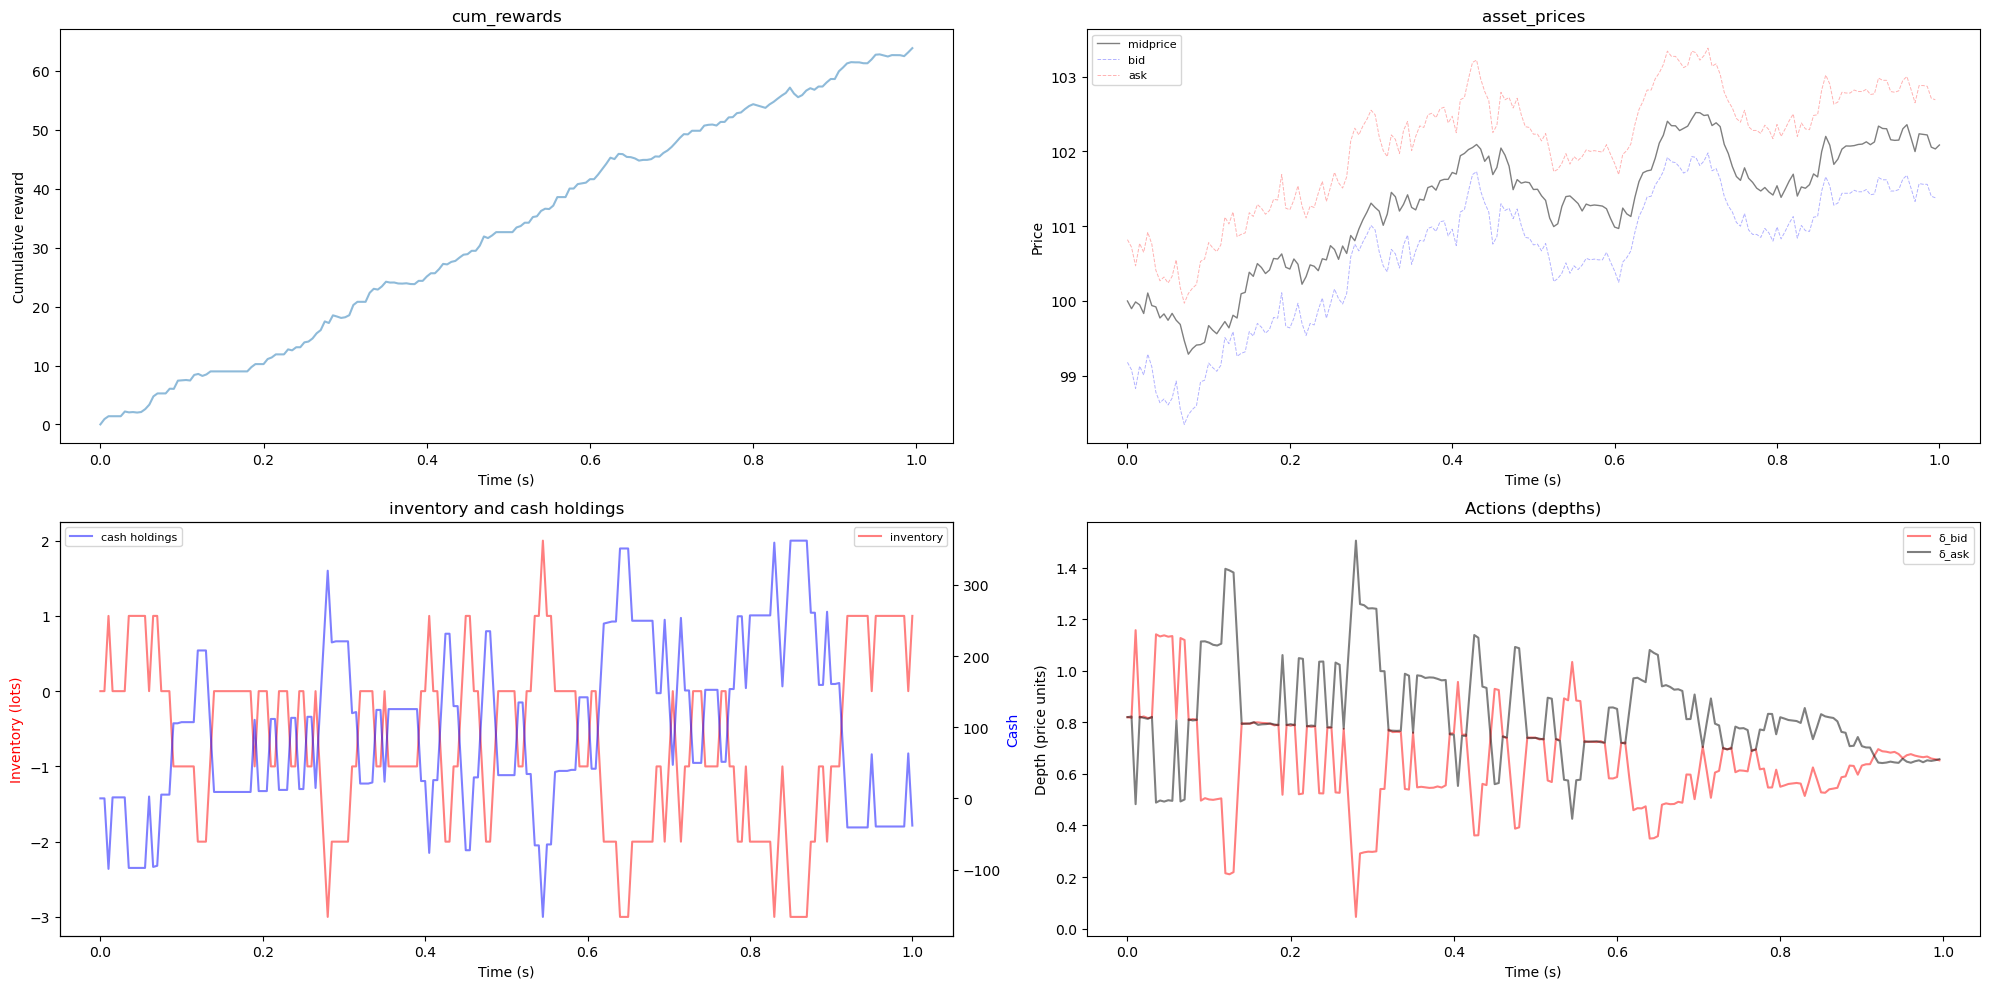

A-S Baseline:
          Mean spread   Mean PnL   Std PnL Mean terminal inventory  \
Inventory    1.476336  65.479382  6.433003                  -0.009   

          Std terminal inventory  
Inventory               2.996484  


In [4]:
as_agent = AvellanedaStoikovAgent(best_gamma, sigma, kappa, T, tick)

# Single trajectory
env1 = get_bm_env(1)
plot_trajectory(env1, as_agent, seed=50)

# Vectorised stats
env_N = get_bm_env(N_train)
results_as, fig_as, _ = generate_results_table_and_hist(env_N, as_agent)
print("A-S Baseline:")
print(results_as)

## 4. Train PPO

In [13]:
%%time
train_env = get_bm_env(N_train, normalise=True, use_cj=True)
sb3_env = StableBaselinesTradingEnvironment(train_env)

model = PPO(
    "MlpPolicy", sb3_env, tensorboard_log=r"C:\Users\john-\Documents\Thesis_AI4T\tb_logs", 
    verbose=1, device="cpu", n_steps=n_steps, 
    batch_size=N_train * n_steps // 4,
    n_epochs=10, learning_rate=3e-4, gamma=best_gamma,
    gae_lambda=0.95, clip_range=0.2, ent_coef=0.01,
)
model.learn(total_timesteps=N_train * n_steps * 100)
print("PPO trained.")

Using cpu device
Logging to C:\Users\john-\Documents\Thesis_AI4T\tb_logs\PPO_1
-------------------------------
| time/              |        |
|    fps             | 576057 |
|    iterations      | 1      |
|    time_elapsed    | 0      |
|    total_timesteps | 200000 |
-------------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 184523       |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 400000       |
| train/                  |              |
|    approx_kl            | 0.0007847338 |
|    clip_fraction        | 0.00011      |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.83        |
|    explained_variance   | -11.6        |
|    learning_rate        | 0.0003       |
|    loss                 | -0.0286      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.000202    |
|    std 

## 5. Validate Learned Policy

Expected A-S patterns:
- δ_bid ↑ with q (long → passive buy)
- δ_ask ↓ with q (long → aggressive sell)
- Both narrow as τ → 0

**RL training diagnostics** (check PPO logs above):
- `explained_variance` → should approach 1.0
- `clip_fraction` → should be 0.05–0.20
- `entropy_loss` → should decrease gradually

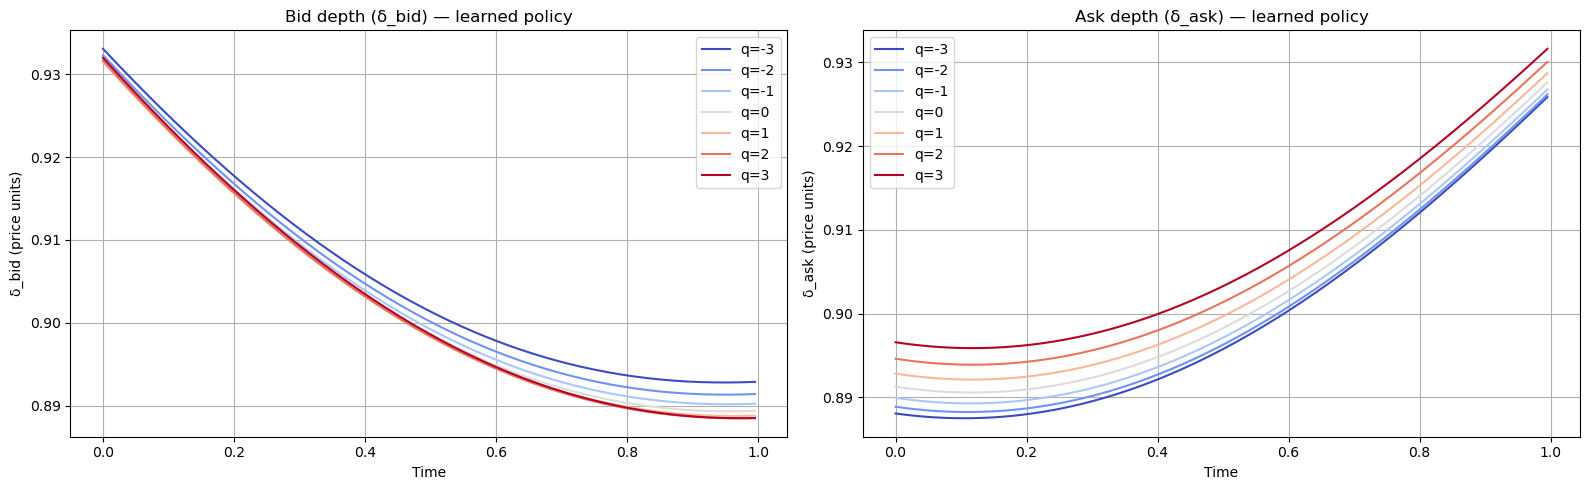

In [14]:
ppo_agent = Sb3Agent(model, train_env=train_env)
plot_learned_policy(ppo_agent, S0, T, n_steps)

## 6. Compare A-S vs PPO

In [15]:
# Both on raw PnLReward envs
vec_as = get_bm_env(N_train)
vec_ppo = get_bm_env(N_train)

stats_as = generate_trajectory_stats(vec_as, as_agent)
stats_ppo = generate_trajectory_stats(vec_ppo, ppo_agent)

comparison = pd.DataFrame({
    "A-S Baseline": {k: stats_as[k].mean() for k in ["sharpe","sortino","max_drawdown","pnl_to_map","total_pnl"]},
    "PPO Agent": {k: stats_ppo[k].mean() for k in ["sharpe","sortino","max_drawdown","pnl_to_map","total_pnl"]},
}).T
print("BM Environment Comparison (N=1000):")
print(comparison.to_string(float_format="%.4f"))

BM Environment Comparison (N=1000):
              sharpe  sortino  max_drawdown  pnl_to_map  total_pnl
A-S Baseline  0.6860   2.2441        1.1360     64.3175    65.5141
PPO Agent     0.4272   0.8941        4.6482     22.1959    64.1246


In [16]:
model.save("C:/Users/john-/Documents/Thesis_AI4T/models/ppo_bm_unconstrained")
print("Model saved.")

Model saved.


['time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/std', 'train/value_loss']


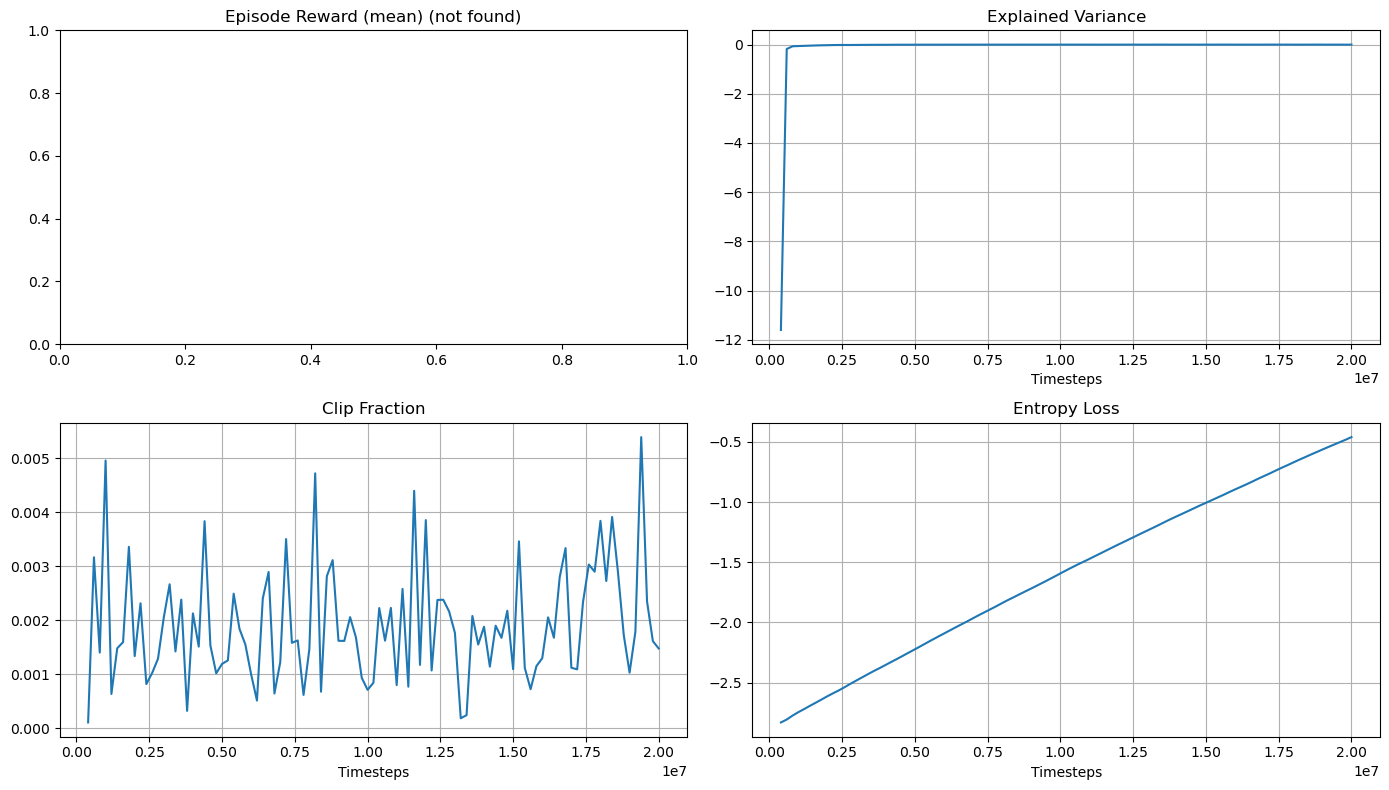

In [18]:
# Load the logs (point to the specific run directory)
ea = event_accumulator.EventAccumulator(r"C:\Users\john-\Documents\Thesis_AI4T\tb_logs\PPO_1")
ea.Reload()

# See what's available
print(ea.Tags()["scalars"])

# Extract specific metrics
def get_scalar(ea, tag):
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]
    return steps, values

# Plot the 4 key diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

metrics = [
    ("rollout/ep_rew_mean", "Episode Reward (mean)"),
    ("train/explained_variance", "Explained Variance"),
    ("train/clip_fraction", "Clip Fraction"),
    ("train/entropy_loss", "Entropy Loss"),
]

for ax, (tag, title) in zip(axes.flat, metrics):
    try:
        steps, values = get_scalar(ea, tag)
        ax.plot(steps, values)
        ax.set_title(title)
        ax.set_xlabel("Timesteps")
        ax.grid(True)
    except KeyError:
        ax.set_title(f"{title} (not found)")

plt.tight_layout()
plt.show()